# Cenário 5 — Recomendação educacional e predição de desempenho acadêmico  
## Agrupamento de Dados I: representação, distância e baseline

**Objetivo desta entrega:** construir um primeiro modelo de agrupamento funcional para identificar perfis acadêmicos/comportamentais de estudantes, justificando as principais decisões técnicas.

Esta etapa cobre:

1. seleção dos atributos para agrupamento;
2. justificativa dos atributos escolhidos;
3. normalização/padronização;
4. definição da medida de distância/similaridade;
5. aplicação do primeiro algoritmo de agrupamento;
6. visualização dos dados;
7. análise inicial dos clusters;
8. identificação de problemas do baseline.

> **Atenção:** este notebook é um baseline. O objetivo não é afirmar que o K-Means é o melhor método, mas criar uma primeira referência para comparação com outro algoritmo na próxima etapa.

## Decisão metodológica inicial

A solução será pensada como um sistema de apoio pedagógico que atua **após o primeiro período letivo**.

Por isso:

- `G1` pode ser usada, pois representa a nota do primeiro período;
- `G2` não será usada no agrupamento, pois representa uma informação posterior;
- `G3` não será usada no agrupamento, pois é a nota final e poderá ser usada depois como variável-alvo na etapa de predição.

Essa decisão evita **vazamento de dados** (*data leakage*): não se deve usar a informação que se pretende prever para criar os próprios grupos.

In [1]:
# ============================================================
# 1. IMPORTAÇÕES E CONFIGURAÇÕES GERAIS
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

In [2]:
# ============================================================
# 2. CARREGAMENTO DA BASE
# ============================================================

# Para executar fora deste ambiente:
# 1. Baixe o arquivo student-por.csv da base Student Performance.
# 2. Coloque o arquivo na mesma pasta deste notebook.
#
# Neste ambiente, o arquivo também pode estar em /mnt/data/student-por.csv.

caminhos_possiveis = [
    Path("student-por.csv"),
    Path("/mnt/data/student-por.csv"),
]

caminho_arquivo = None

for caminho in caminhos_possiveis:
    if caminho.exists():
        caminho_arquivo = caminho
        break

if caminho_arquivo is None:
    raise FileNotFoundError(
        "Arquivo student-por.csv não encontrado. "
        "Coloque o arquivo na mesma pasta deste notebook."
    )

df = pd.read_csv(caminho_arquivo, sep=";")

print(f"Arquivo carregado: {caminho_arquivo}")
print(f"Dimensão da base: {df.shape[0]} linhas x {df.shape[1]} colunas")

display(df.head())

Arquivo carregado: student-por.csv
Dimensão da base: 649 linhas x 33 colunas


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


## 3. Análise exploratória mínima

Antes do agrupamento, precisamos verificar:

- tipos dos atributos;
- existência de valores ausentes;
- existência de registros duplicados;
- distribuição inicial das variáveis principais;
- comportamento das notas `G1`, `G2` e `G3`.

Essa análise ajuda a evitar decisões automáticas e pouco justificadas.

In [3]:
# ============================================================
# 3. VERIFICAÇÕES INICIAIS
# ============================================================

print("Tipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por atributo:")
ausentes = df.isna().sum().sort_values(ascending=False)
display(ausentes.to_frame("qtd_ausentes"))

print("\nQuantidade de registros duplicados:")
print(df.duplicated().sum())

print("\nResumo estatístico de atributos acadêmicos e comportamentais:")
atributos_resumo = [
    "G1", "G2", "G3",
    "studytime", "failures", "absences",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
]

display(df[atributos_resumo].describe().T)

Tipos de dados:


,tipo
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object



Valores ausentes por atributo:


,qtd_ausentes
school,0
paid,0
G2,0
G1,0
absences,0
health,0
Walc,0
Dalc,0
goout,0
freetime,0



Quantidade de registros duplicados:
0

Resumo estatístico de atributos acadêmicos e comportamentais:


,count,mean,std,min,25%,50%,75%,max
G1,649.0,11.399076,2.745265,0.0,10.0,11.0,13.0,19.0
G2,649.0,11.570108,2.913639,0.0,10.0,11.0,13.0,19.0
G3,649.0,11.906009,3.230656,0.0,10.0,12.0,14.0,19.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
absences,649.0,3.659476,4.640759,0.0,0.0,2.0,6.0,32.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


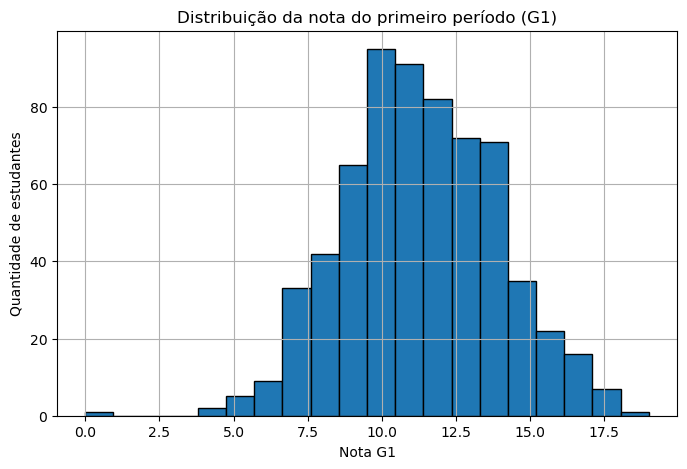

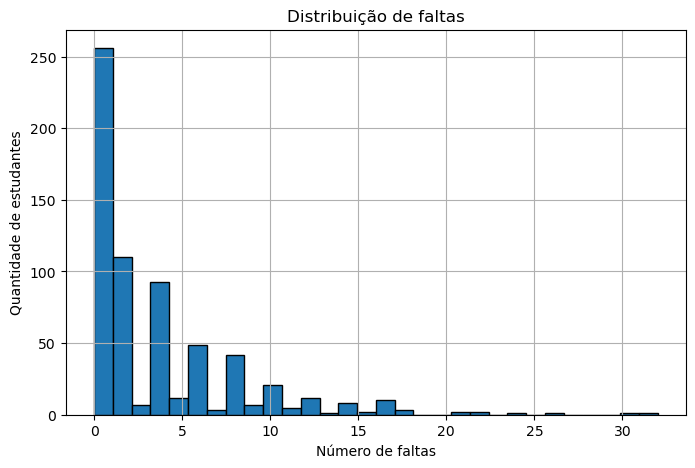

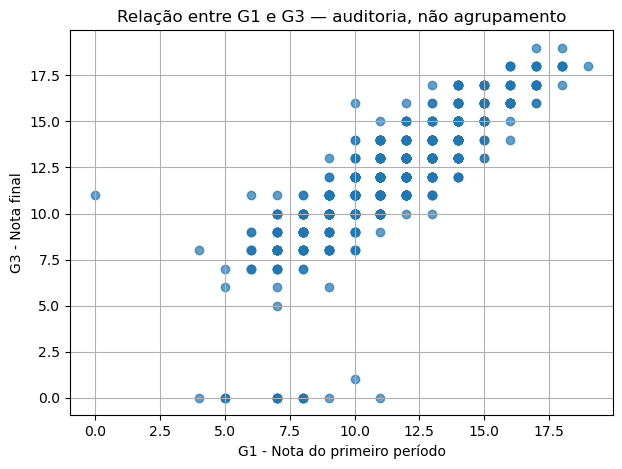

In [4]:
# ============================================================
# 4. VISUALIZAÇÕES EXPLORATÓRIAS INICIAIS
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["G1"], bins=20, edgecolor="black")
plt.xlabel("Nota G1")
plt.ylabel("Quantidade de estudantes")
plt.title("Distribuição da nota do primeiro período (G1)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["absences"], bins=30, edgecolor="black")
plt.xlabel("Número de faltas")
plt.ylabel("Quantidade de estudantes")
plt.title("Distribuição de faltas")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(df["G1"], df["G3"], alpha=0.7)
plt.xlabel("G1 - Nota do primeiro período")
plt.ylabel("G3 - Nota final")
plt.title("Relação entre G1 e G3 — auditoria, não agrupamento")
plt.grid(True)
plt.show()

## 4. Seleção dos atributos para agrupamento

A seleção dos atributos deve considerar a pergunta do cenário:

> Como agrupar estudantes por perfil acadêmico/comportamental e usar esses grupos para prever desempenho ou recomendar intervenções?

Neste baseline, foram selecionados atributos que:

1. estão disponíveis até o primeiro período;
2. podem caracterizar desempenho inicial, dedicação, frequência e comportamento;
3. podem orientar intervenções pedagógicas;
4. possuem interpretação educacional relativamente clara.

### Atributos selecionados

| Atributo | Motivo da inclusão |
|---|---|
| `G1` | Indicador inicial de desempenho acadêmico. |
| `studytime` | Representa dedicação semanal aos estudos. |
| `failures` | Indica histórico de reprovações anteriores. |
| `absences` | Indica frequência escolar e possível desengajamento. |
| `schoolsup` | Mostra se o estudante já recebe apoio educacional da escola. |
| `famsup` | Indica apoio educacional da família. |
| `activities` | Indica participação em atividades extracurriculares. |
| `famrel` | Contextualiza relações familiares. |
| `freetime` | Representa tempo livre após a escola. |
| `goout` | Representa frequência de saídas com amigos. |
| `Dalc` | Consumo de álcool durante a semana. |
| `Walc` | Consumo de álcool no fim de semana. |
| `health` | Estado atual de saúde. |

### Atributos excluídos neste baseline

| Atributo | Motivo da exclusão |
|---|---|
| `G2` | Informação posterior ao momento da intervenção. |
| `G3` | Nota final; será usada depois para predição/auditoria. |
| `sex`, `address`, `school`, `Medu`, `Fedu`, `Mjob`, `Fjob` | Podem ser úteis para auditoria, mas podem introduzir vieses ou segmentações sensíveis no baseline. |
| Demais variáveis categóricas | Poderão ser avaliadas em versões futuras, mas aumentam a complexidade do primeiro baseline. |

In [5]:
# ============================================================
# 5. SELEÇÃO DOS ATRIBUTOS DO BASELINE
# ============================================================

atributos_selecionados = [
    "G1",
    "studytime",
    "failures",
    "absences",
    "schoolsup",
    "famsup",
    "activities",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
]

df_modelo = df[atributos_selecionados].copy()

print("Atributos selecionados para o baseline:")
for atributo in atributos_selecionados:
    print("-", atributo)

display(df_modelo.head())

Atributos selecionados para o baseline:
- G1
- studytime
- failures
- absences
- schoolsup
- famsup
- activities
- famrel
- freetime
- goout
- Dalc
- Walc
- health


,G1,studytime,failures,absences,schoolsup,famsup,activities,famrel,freetime,goout,Dalc,Walc,health
0,0,2,0,4,yes,no,no,4,3,4,1,1,3
1,9,2,0,2,no,yes,no,5,3,3,1,1,3
2,12,2,0,6,yes,no,no,4,3,2,2,3,3
3,14,3,0,0,no,yes,yes,3,2,2,1,1,5
4,11,2,0,0,no,yes,no,4,3,2,1,2,5


## 5. Representação dos dados

O K-Means exige atributos numéricos. Portanto, os atributos binários `yes/no` serão convertidos para `1/0`.

Além disso, o atributo `absences` será transformado com `log1p`, pois a quantidade de faltas tende a ser assimétrica e pode conter valores mais altos do que os demais atributos.

A transformação usada será:

\[
\log(1 + \text{absences})
\]

Ela reduz o efeito de valores extremos e permite lidar corretamente com estudantes com zero faltas.

In [6]:
# ============================================================
# 6. TRANSFORMAÇÃO DAS VARIÁVEIS
# ============================================================

# Conversão de variáveis binárias
atributos_binarios = ["schoolsup", "famsup", "activities"]

for atributo in atributos_binarios:
    df_modelo[atributo] = df_modelo[atributo].map({"yes": 1, "no": 0})

# Validação da conversão
if df_modelo[atributos_binarios].isna().any().any():
    raise ValueError("Há valores inesperados em variáveis binárias.")

# Manter a versão original das faltas para interpretação posterior
df_modelo["absences_original"] = df_modelo["absences"]

# Transformação logarítmica das faltas
df_modelo["absences_log1p"] = np.log1p(df_modelo["absences"])

# Atributos efetivamente usados no agrupamento
atributos_modelagem = [
    "G1",
    "studytime",
    "failures",
    "absences_log1p",
    "schoolsup",
    "famsup",
    "activities",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
]

X = df_modelo[atributos_modelagem].copy()

print("Base numérica pronta para padronização:")
display(X.head())

print("\nResumo após transformações:")
display(X.describe().T)

Base numérica pronta para padronização:


,G1,studytime,failures,absences_log1p,schoolsup,famsup,activities,famrel,freetime,goout,Dalc,Walc,health
0,0,2,0,1.609438,1,0,0,4,3,4,1,1,3
1,9,2,0,1.098612,0,1,0,5,3,3,1,1,3
2,12,2,0,1.945910,1,0,0,4,3,2,2,3,3
3,14,3,0,0.000000,0,1,1,3,2,2,1,1,5
4,11,2,0,0.000000,0,1,0,4,3,2,1,2,5



Resumo após transformações:


,count,mean,std,min,25%,50%,75%,max
G1,649.0,11.399076,2.745265,0.0,10.0,11.000000,13.00000,19.000000
studytime,649.0,1.930663,0.829510,1.0,1.0,2.000000,2.00000,4.000000
failures,649.0,0.221880,0.593235,0.0,0.0,0.000000,0.00000,3.000000
absences_log1p,649.0,1.088613,0.964296,0.0,0.0,1.098612,1.94591,3.496508
schoolsup,649.0,0.104777,0.306502,0.0,0.0,0.000000,0.00000,1.000000
famsup,649.0,0.613251,0.487381,0.0,0.0,1.000000,1.00000,1.000000
activities,649.0,0.485362,0.500171,0.0,0.0,0.000000,1.00000,1.000000
famrel,649.0,3.930663,0.955717,1.0,4.0,4.000000,5.00000,5.000000
freetime,649.0,3.180277,1.051093,1.0,3.0,3.000000,4.00000,5.000000
goout,649.0,3.184900,1.175766,1.0,2.0,3.000000,4.00000,5.000000


## 6. Padronização dos atributos

Será aplicado `StandardScaler`, que coloca os atributos em escala comparável, com média aproximadamente 0 e desvio padrão aproximadamente 1.

### Justificativa

Sem padronização, atributos com maior escala poderiam dominar a distância Euclidiana. Por exemplo:

- `absences` pode ter valores muito maiores que variáveis binárias;
- `G1` varia de 0 a 20;
- `studytime`, `famrel`, `freetime`, `goout`, `Dalc`, `Walc` e `health` usam escalas menores;
- `schoolsup`, `famsup` e `activities` variam apenas entre 0 e 1.

Como o agrupamento depende da distância entre os estudantes, as escalas precisam ser comparáveis.

In [7]:
# ============================================================
# 7. PADRONIZAÇÃO
# ============================================================

scaler = StandardScaler()
X_padronizado_array = scaler.fit_transform(X)

X_padronizado = pd.DataFrame(
    X_padronizado_array,
    columns=atributos_modelagem,
    index=df.index,
)

print("Médias após padronização:")
display(X_padronizado.mean().round(4).to_frame("media"))

print("Desvios padrão após padronização:")
display(X_padronizado.std(ddof=0).round(4).to_frame("desvio_padrao"))

Médias após padronização:


,media
G1,0.0
studytime,0.0
failures,0.0
absences_log1p,0.0
schoolsup,-0.0
famsup,-0.0
activities,0.0
famrel,-0.0
freetime,0.0
goout,0.0


Desvios padrão após padronização:


,desvio_padrao
G1,1.0
studytime,1.0
failures,1.0
absences_log1p,1.0
schoolsup,1.0
famsup,1.0
activities,1.0
famrel,1.0
freetime,1.0
goout,1.0


## 7. Medida de distância e algoritmo baseline

### Medida de distância

Para este baseline será usada a **distância Euclidiana**, coerente com o funcionamento do K-Means.

### Algoritmo inicial

Será utilizado **K-Means** como primeiro algoritmo de agrupamento porque:

- é simples de interpretar;
- é eficiente;
- permite testar diferentes valores de `k`;
- gera centroides que podem ser analisados como perfis médios.

### Limitação reconhecida

A base possui atributos numéricos, ordinais e binários. A distância Euclidiana é aceitável como baseline após padronização, mas não representa perfeitamente dados mistos.

Na próxima entrega, o grupo deverá comparar este resultado com outro algoritmo ou outra representação.

## 8. Escolha inicial do número de clusters

O número de clusters não deve ser escolhido automaticamente.

Neste notebook, testaremos:

\[
k = 2, 3, 4, 5, 6
\]

A decisão será apoiada por:

- SSE/inércia;
- silhouette médio;
- Davies-Bouldin;
- Calinski-Harabasz;
- tamanho dos clusters;
- interpretação pedagógica dos perfis.

O maior silhouette não deve ser adotado sem analisar se os clusters possuem sentido pedagógico.

In [8]:
# ============================================================
# 8. TESTE DE DIFERENTES VALORES DE K
# ============================================================

resultados_k = []

for k in range(2, 7):
    modelo = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )

    rotulos = modelo.fit_predict(X_padronizado)

    contagens = pd.Series(rotulos).value_counts().sort_index().to_dict()

    resultados_k.append(
        {
            "k": k,
            "sse_inercia": modelo.inertia_,
            "silhouette": silhouette_score(X_padronizado, rotulos),
            "davies_bouldin": davies_bouldin_score(X_padronizado, rotulos),
            "calinski_harabasz": calinski_harabasz_score(X_padronizado, rotulos),
            "tamanho_menor_cluster": min(contagens.values()),
            "tamanhos_clusters": contagens,
        }
    )

df_resultados_k = pd.DataFrame(resultados_k)

print("Comparação entre valores de k:")
display(df_resultados_k.round(4))

Comparação entre valores de k:


,k,sse_inercia,silhouette,davies_bouldin,calinski_harabasz,tamanho_menor_cluster,tamanhos_clusters
0,2,7415.7726,0.1456,2.4917,89.0985,207,"{0: 442, 1: 207}"
1,3,6821.1855,0.1547,2.2058,76.5128,66,"{0: 384, 1: 199, 2: 66}"
2,4,6371.4071,0.1056,2.3295,69.7024,66,"{0: 66, 1: 158, 2: 174, 3: 251}"
3,5,5991.6533,0.1116,2.1998,65.7082,57,"{0: 63, 1: 57, 2: 195, 3: 218, 4: 116}"
4,6,5703.4980,0.1062,2.1133,61.6338,50,"{0: 179, 1: 113, 2: 131, 3: 113, 4: 50, 5: 63}"


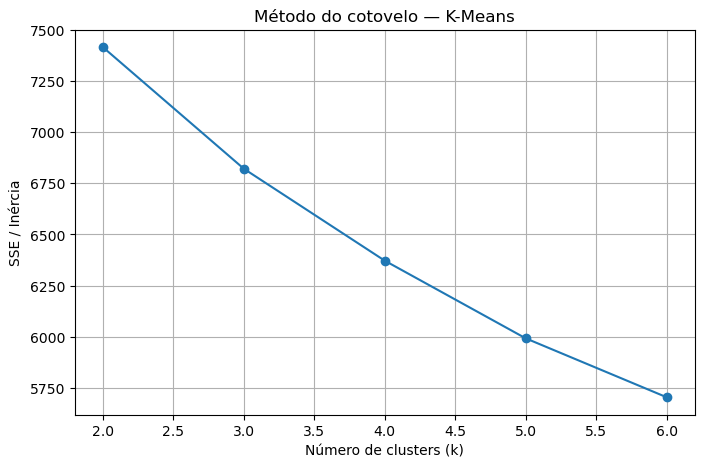

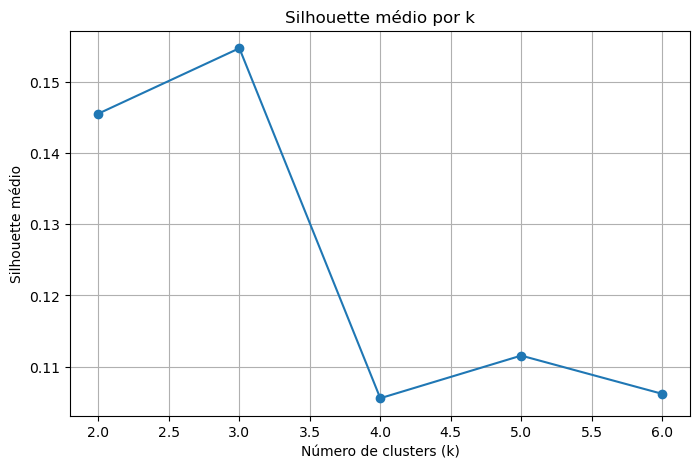

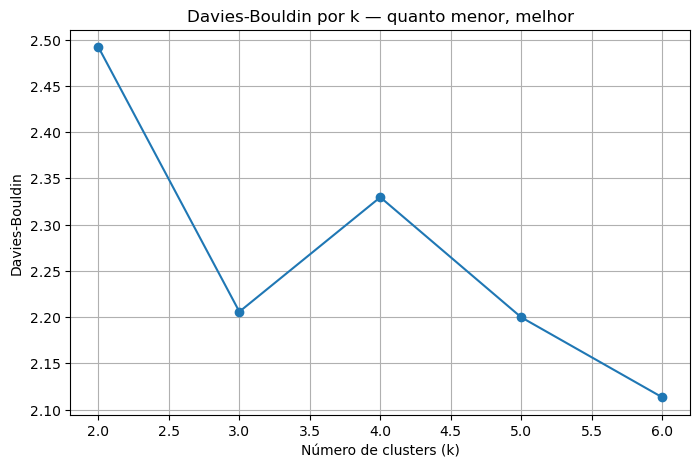

In [9]:
# ============================================================
# 9. VISUALIZAÇÃO DAS MÉTRICAS POR K
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(df_resultados_k["k"], df_resultados_k["sse_inercia"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("SSE / Inércia")
plt.title("Método do cotovelo — K-Means")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_resultados_k["k"], df_resultados_k["silhouette"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette médio")
plt.title("Silhouette médio por k")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_resultados_k["k"], df_resultados_k["davies_bouldin"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin")
plt.title("Davies-Bouldin por k — quanto menor, melhor")
plt.grid(True)
plt.show()

## 9. Escolha do valor de `k`

Para automatizar o baseline, o notebook seleciona inicialmente o `k` com maior silhouette.

Entretanto, os alunos devem verificar se a escolha faz sentido:

1. o cluster menor é grande o suficiente?
2. os perfis são interpretáveis?
3. os grupos permitem intervenções pedagógicas diferentes?
4. o ganho de métrica compensa a complexidade de mais clusters?

Se a equipe discordar da escolha automática, poderá alterar manualmente a variável `k_escolhido`.

In [10]:
# ============================================================
# 10. ESCOLHA INICIAL DE K
# ============================================================

linha_melhor_silhouette = df_resultados_k.sort_values(
    by="silhouette",
    ascending=False,
).iloc[0]

k_sugerido = int(linha_melhor_silhouette["k"])

print(f"k sugerido pelo maior silhouette: {k_sugerido}")

# Caso a equipe queira escolher outro valor com base na interpretação pedagógica,
# altere a linha abaixo. Exemplo: k_escolhido = 3
k_escolhido = k_sugerido

print(f"k adotado no baseline: {k_escolhido}")

k sugerido pelo maior silhouette: 3
k adotado no baseline: 3


In [11]:
# ============================================================
# 11. TREINAMENTO DO K-MEANS FINAL DO BASELINE
# ============================================================

kmeans = KMeans(
    n_clusters=k_escolhido,
    random_state=RANDOM_STATE,
    n_init=20,
)

df_modelo["cluster"] = kmeans.fit_predict(X_padronizado)

print("Quantidade de estudantes por cluster:")
display(df_modelo["cluster"].value_counts().sort_index().to_frame("quantidade"))

Quantidade de estudantes por cluster:


,quantidade
cluster,
0,384
1,199
2,66


## 10. Interpretação inicial dos clusters

A interpretação não deve ser feita pelo número do cluster. Os rótulos `0`, `1`, `2` etc. são arbitrários.

Para interpretar os perfis, analisaremos:

- quantidade de estudantes;
- média de `G1`;
- tempo médio de estudo;
- histórico de reprovações;
- média e mediana de faltas;
- presença de apoio escolar e familiar;
- variáveis comportamentais.

Depois disso, a equipe deverá propor nomes pedagógicos para os clusters.

In [12]:
# ============================================================
# 12. TABELA DE PERFIL DOS CLUSTERS
# ============================================================

resumo_clusters = (
    df_modelo
    .groupby("cluster")
    .agg(
        quantidade_estudantes=("cluster", "size"),
        media_G1=("G1", "mean"),
        mediana_G1=("G1", "median"),
        media_tempo_estudo=("studytime", "mean"),
        media_reprovacoes=("failures", "mean"),
        mediana_faltas=("absences_original", "median"),
        media_faltas=("absences_original", "mean"),
        percentual_apoio_escola=("schoolsup", "mean"),
        percentual_apoio_familia=("famsup", "mean"),
        percentual_atividades=("activities", "mean"),
        media_relacao_familiar=("famrel", "mean"),
        media_tempo_livre=("freetime", "mean"),
        media_saidas_amigos=("goout", "mean"),
        media_alcool_semana=("Dalc", "mean"),
        media_alcool_fim_semana=("Walc", "mean"),
        media_saude=("health", "mean"),
    )
)

colunas_percentuais = [
    "percentual_apoio_escola",
    "percentual_apoio_familia",
    "percentual_atividades",
]

resumo_clusters[colunas_percentuais] = resumo_clusters[colunas_percentuais] * 100

print("Resumo interpretável dos clusters:")
display(resumo_clusters.round(2))

Resumo interpretável dos clusters:


,quantidade_estudantes,media_G1,mediana_G1,media_tempo_estudo,media_reprovacoes,mediana_faltas,media_faltas,percentual_apoio_escola,percentual_apoio_familia,percentual_atividades,media_relacao_familiar,media_tempo_livre,media_saidas_amigos,media_alcool_semana,media_alcool_fim_semana,media_saude
cluster,,,,,,,,,,,,,,,,
0,384,12.36,12.0,2.08,0.07,2.0,2.90,0.00,63.28,47.14,4.02,2.99,2.83,1.13,1.69,3.40
1,199,9.72,10.0,1.55,0.51,4.0,5.42,1.01,54.27,53.27,3.78,3.58,3.96,2.28,3.58,3.77
2,66,10.86,11.0,2.18,0.23,2.0,2.76,100.00,71.21,42.42,3.88,3.08,2.92,1.32,1.82,3.61


In [13]:
# ============================================================
# 13. CENTROIDES EM ESCALA ORIGINAL APROXIMADA
# ============================================================

centroides_padronizados = kmeans.cluster_centers_
centroides_escala_original = scaler.inverse_transform(centroides_padronizados)

df_centroides = pd.DataFrame(
    centroides_escala_original,
    columns=atributos_modelagem,
)

# Reverter absences_log1p para escala aproximada de faltas
df_centroides["absences_aproximado"] = np.expm1(df_centroides["absences_log1p"])
df_centroides = df_centroides.drop(columns=["absences_log1p"])

print("Centroides aproximados em escala original:")
display(df_centroides.round(2))

Centroides aproximados em escala original:


,G1,studytime,failures,schoolsup,famsup,activities,famrel,freetime,goout,Dalc,Walc,health,absences_aproximado
0,12.36,2.08,0.07,0.00,0.63,0.47,4.02,2.99,2.83,1.13,1.69,3.40,1.55
1,9.72,1.55,0.51,0.01,0.54,0.53,3.78,3.58,3.96,2.28,3.58,3.77,3.22
2,10.86,2.18,0.23,1.00,0.71,0.42,3.88,3.08,2.92,1.32,1.82,3.61,1.53


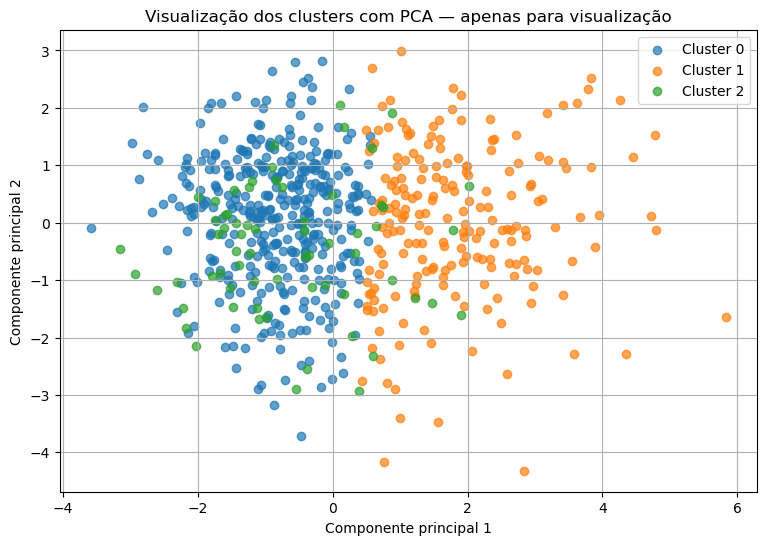

Variância explicada pelos dois componentes: 0.2895


In [14]:
# ============================================================
# 14. VISUALIZAÇÃO COM PCA
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coordenadas_pca = pca.fit_transform(X_padronizado)

df_visualizacao = pd.DataFrame(
    coordenadas_pca,
    columns=["PC1", "PC2"],
    index=df.index,
)

df_visualizacao["cluster"] = df_modelo["cluster"]

plt.figure(figsize=(9, 6))

for cluster in sorted(df_visualizacao["cluster"].unique()):
    dados_cluster = df_visualizacao[df_visualizacao["cluster"] == cluster]
    plt.scatter(
        dados_cluster["PC1"],
        dados_cluster["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7,
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Visualização dos clusters com PCA — apenas para visualização")
plt.legend()
plt.grid(True)
plt.show()

variancia_explicada = pca.explained_variance_ratio_.sum()
print(f"Variância explicada pelos dois componentes: {variancia_explicada:.4f}")

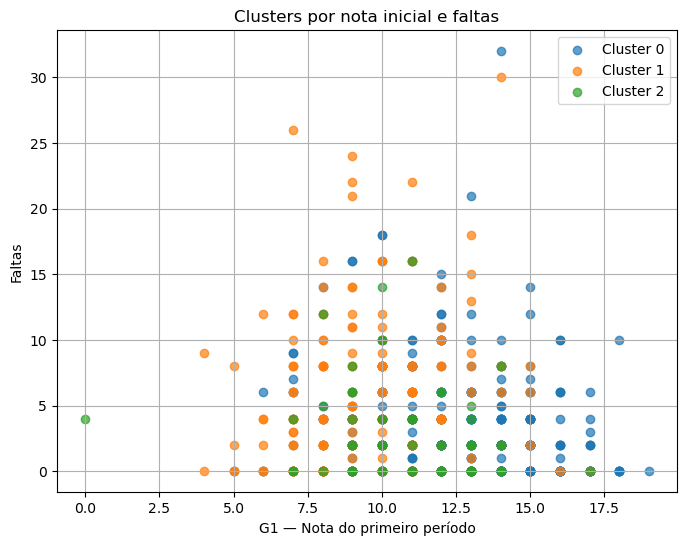

In [15]:
# ============================================================
# 15. VISUALIZAÇÃO PEDAGÓGICA SIMPLES
# ============================================================

plt.figure(figsize=(8, 6))
for cluster in sorted(df_modelo["cluster"].unique()):
    dados_cluster = df_modelo[df_modelo["cluster"] == cluster]
    plt.scatter(
        dados_cluster["G1"],
        dados_cluster["absences_original"],
        label=f"Cluster {cluster}",
        alpha=0.7,
    )

plt.xlabel("G1 — Nota do primeiro período")
plt.ylabel("Faltas")
plt.title("Clusters por nota inicial e faltas")
plt.legend()
plt.grid(True)
plt.show()

## 11. Auditoria com `G2` e `G3`

A variável `G3` não foi usada para formar clusters. Porém, ela pode ser analisada depois para verificar se os perfis encontrados se relacionam com o desempenho final.

Essa análise é apenas uma **auditoria posterior**, não parte da formação dos grupos.

In [16]:
# ============================================================
# 16. AUDITORIA POSTERIOR COM G2 E G3
# ============================================================

df_auditoria = pd.DataFrame({
    "cluster": df_modelo["cluster"],
    "G1": df["G1"],
    "G2": df["G2"],
    "G3": df["G3"],
})

auditoria_clusters = (
    df_auditoria
    .groupby("cluster")
    .agg(
        quantidade=("cluster", "size"),
        G1_media=("G1", "mean"),
        G2_media=("G2", "mean"),
        G3_media=("G3", "mean"),
        G3_mediana=("G3", "median"),
        G3_desvio=("G3", "std"),
    )
)

print("Auditoria de notas por cluster:")
display(auditoria_clusters.round(2))

Auditoria de notas por cluster:


,quantidade,G1_media,G2_media,G3_media,G3_mediana,G3_desvio
cluster,,,,,,
0,384,12.36,12.53,13.00,13.0,2.80
1,199,9.72,9.86,10.01,10.0,3.35
2,66,10.86,11.14,11.26,11.0,2.23


## 12. Nomeação inicial dos perfis

Preencha a tabela abaixo após analisar `resumo_clusters`, `df_centroides` e a auditoria com `G3`.

Exemplo de nomes possíveis:

- bom desempenho e rotina equilibrada;
- risco acadêmico por baixo desempenho;
- baixa frequência;
- dificuldade apesar de apoio escolar;
- perfil comportamental de atenção.

Atenção: não use esses nomes automaticamente. Eles precisam ser coerentes com os valores observados.

In [17]:
# ============================================================
# 17. TABELA PARA OS ALUNOS PREENCHEREM
# ============================================================

tabela_interpretacao = pd.DataFrame({
    "cluster": sorted(df_modelo["cluster"].unique()),
    "caracteristicas_predominantes": "",
    "nome_proposto": "",
    "intervencao_pedagogica_sugerida": "",
    "limitacoes_da_interpretacao": "",
})

display(tabela_interpretacao)

,cluster,caracteristicas_predominantes,nome_proposto,intervencao_pedagogica_sugerida,limitacoes_da_interpretacao
0,0,,,,
1,1,,,,
2,2,,,,


## 13. Problemas e limitações esperadas do baseline

Nesta etapa, a equipe deve reconhecer limitações do primeiro modelo.

### Limitações importantes

1. **Mistura de tipos de atributos:** há variáveis numéricas, ordinais e binárias.
2. **Distância Euclidiana:** simplifica a noção de similaridade entre estudantes.
3. **Sensibilidade do K-Means a outliers:** estudantes com muitas faltas podem influenciar os centroides.
4. **Forma dos clusters:** K-Means favorece grupos compactos e aproximadamente esféricos.
5. **Interpretação pedagógica:** boa métrica não garante utilidade educacional.
6. **Possíveis vieses:** atributos demográficos e socioeconômicos foram excluídos do baseline, mas devem ser auditados futuramente.

### Próximos passos recomendados

- comparar com agrupamento hierárquico;
- comparar com K-Medoids ou distância de Gower;
- testar outro conjunto de atributos;
- avaliar estabilidade dos clusters;
- usar os clusters como entrada para árvore de decisão, rede neural ou recomendador.

In [18]:
# ============================================================
# 18. SALVAR RESULTADOS DO BASELINE
# ============================================================

saida_clusters = df.copy()
saida_clusters["cluster_baseline"] = df_modelo["cluster"]

saida_clusters.to_csv("student_por_com_clusters_baseline.csv", index=False)
df_resultados_k.to_csv("comparacao_k_baseline.csv", index=False)
resumo_clusters.to_csv("resumo_clusters_baseline.csv")

print("Arquivos gerados:")
print("- student_por_com_clusters_baseline.csv")
print("- comparacao_k_baseline.csv")
print("- resumo_clusters_baseline.csv")

Arquivos gerados:
- student_por_com_clusters_baseline.csv
- comparacao_k_baseline.csv
- resumo_clusters_baseline.csv


# 14. Conclusão esperada da entrega

Ao final desta etapa, a equipe deverá escrever uma conclusão contendo:

1. quais atributos foram usados e por quê;
2. quais atributos foram excluídos e por quê;
3. qual transformação foi aplicada;
4. por que a padronização foi necessária;
5. por que a distância Euclidiana foi usada no baseline;
6. qual valor de `k` foi escolhido;
7. quais evidências sustentam essa escolha;
8. quais perfis foram encontrados;
9. quais limitações o baseline possui;
10. qual será o próximo algoritmo ou abordagem a ser comparado na entrega seguinte.

## Conclusão

> O baseline foi construído com K-Means e distância Euclidiana sobre atributos acadêmicos e comportamentais padronizados. A variável `G1` foi incluída como indicador precoce de desempenho, enquanto `G2` e `G3` foram excluídas para evitar uso de informações futuras. A variável `absences` foi transformada com `log1p` para reduzir o efeito de valores extremos.  
>
> Foram testados valores de `k` entre 2 e 6, comparando SSE, silhouette, Davies-Bouldin, Calinski-Harabasz, tamanho dos clusters e interpretação pedagógica. O valor de `k` adotado foi justificado com base no equilíbrio entre qualidade métrica e utilidade educacional.  
>
> Os clusters encontrados representam uma primeira tentativa de identificar perfis acadêmicos/comportamentais. Entretanto, o baseline possui limitações relacionadas à mistura de tipos de atributos, à distância Euclidiana e à sensibilidade do K-Means. Na próxima etapa, o grupo deverá comparar os resultados com outro algoritmo e avaliar se os perfis podem apoiar recomendações pedagógicas personalizadas.